In [1]:
import matplotlib.pyplot as plt
import numpy as np

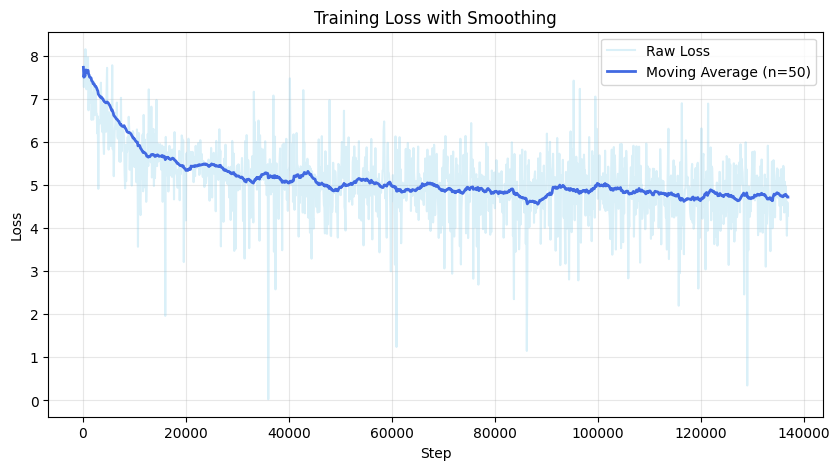

In [2]:
import matplotlib.pyplot as plt

x = []
y = []
offset = 0

with open("pretraining_log.txt", 'r', encoding='utf-8') as f:
    while True:
        line = f.readline()
        if line == "":
            break
        line = line.strip()
        if "|" in line:
            d = line.split()
            try:
                loss = float(d[4])
                step = int(d[1])
                
                # --- Your original logic restored ---
                if offset + step in x:
                    offset = x[-1]
                
                x.append(step + offset)
                y.append(loss)
            except (ValueError, IndexError):
                continue

# --- Adding Moving Average (Standard Python) ---
window_size = 50
moving_avg = []

for i in range(len(y)):
    # Calculate the average of the last 'window_size' points
    start_idx = max(0, i - window_size + 1)
    window = y[start_idx : i + 1]
    avg = sum(window) / len(window)
    moving_avg.append(avg)

# --- Plotting ---
plt.figure(figsize=(10, 5))

# Plot raw data (faded)
plt.plot(x, y, color='skyblue', alpha=0.3, label='Raw Loss')

# Plot moving average (solid)
plt.plot(x, moving_avg, color='royalblue', linewidth=2, label=f'Moving Average (n={window_size})')

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss with Smoothing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

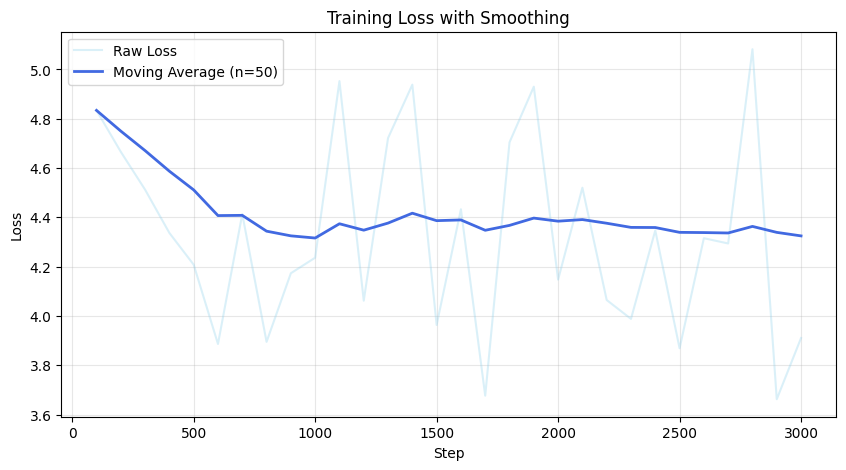

In [3]:
import matplotlib.pyplot as plt

x = []
y = []
offset = 0

with open("task_lm_training_log.txt", 'r', encoding='utf-8') as f:
    while True:
        line = f.readline()
        if line == "":
            break
        line = line.strip()
        if "|" in line:
            d = line.split()
            try:
                loss = float(d[4])
                step = int(d[1])
                
                # --- Your original logic restored ---
                if offset + step in x:
                    offset = x[-1]
                
                x.append(step + offset)
                y.append(loss)
            except (ValueError, IndexError):
                continue

# --- Adding Moving Average (Standard Python) ---
window_size = 50
moving_avg = []

for i in range(len(y)):
    # Calculate the average of the last 'window_size' points
    start_idx = max(0, i - window_size + 1)
    window = y[start_idx : i + 1]
    avg = sum(window) / len(window)
    moving_avg.append(avg)

# --- Plotting ---
plt.figure(figsize=(10, 5))

# Plot raw data (faded)
plt.plot(x, y, color='skyblue', alpha=0.3, label='Raw Loss')

# Plot moving average (solid)
plt.plot(x, moving_avg, color='royalblue', linewidth=2, label=f'Moving Average (n={window_size})')

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss with Smoothing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
for row in range(2):
            for col in range(2):
                val = cm[row, col]
                color = "white" if val > (max_val * 0.6) else "black"
                ax.text(col, row, str(val),
                        ha="center", va="center",
                        color=color, fontsize=18, fontweight='bold')

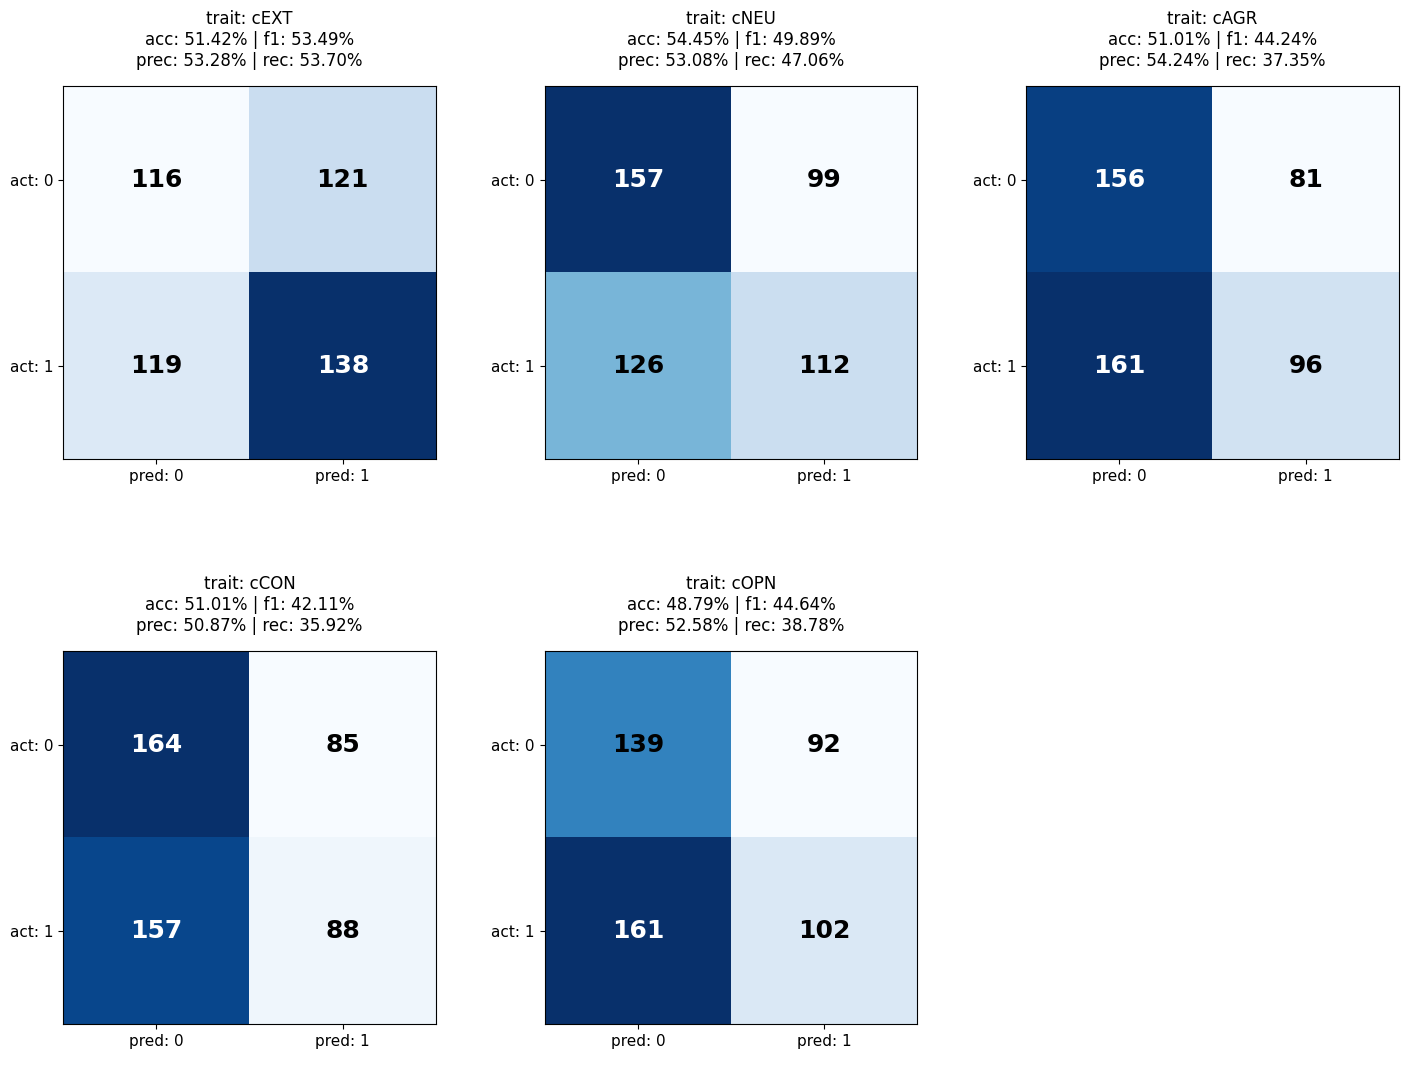

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import re

def parse_results_file(file_path):
    traits_data = {}
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            
        # Tách nội dung theo từng trait (cEXT, cNEU,...)
        blocks = re.split(r'\n(?=c[A-Z]{3})', content.strip())
        
        for block in blocks:
            lines = block.strip().split('\n')
            if not lines: continue
            
            trait_name = lines[0].strip() 
            
            # Trích xuất ma trận nhầm lẫn
            matrix_values = re.findall(r'\|\s+(\d+)\s+\|\s+(\d+)', block)
            if len(matrix_values) >= 2:
                row0 = [int(x) for x in matrix_values[0]]
                row1 = [int(x) for x in matrix_values[1]]
                matrix = np.array([row0, row1])
            
            # Trích xuất các chỉ số (Accuracy, F1, Precision, Recall)
            acc = re.search(r'Accuracy:\s+([\d.]*%)', block)
            prec = re.search(r'Precision:\s+([\d.]*%)', block)
            rec = re.search(r'Recall:\s+([\d.]*%)', block)
            f1 = re.search(r'F1-score:\s+([\d.]*%)', block)
            
            if trait_name and acc and f1:
                traits_data[trait_name] = {
                    "matrix": matrix,
                    "acc": acc.group(1) if acc else "N/A",
                    "prec": prec.group(1) if prec else "N/A",
                    "rec": rec.group(1) if rec else "N/A",
                    "f1": f1.group(1) if f1 else "N/A"
                }
                
        return traits_data

    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return None

def draw_graphs(traits_data):
    if not traits_data:
        return

    trait_keys = list(traits_data.keys())
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 12)) # Tăng chiều cao để đủ chỗ cho tiêu đề
    axes = axes.flatten()

    for i, key in enumerate(trait_keys):
        ax = axes[i]
        data = traits_data[key]
        cm = data["matrix"]
        
        # 1. Vẽ Heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        
        # 2. Định dạng Tiêu đề (Bao gồm cả Precision và Recall)
        # Sử dụng 2 dòng để tiêu đề gọn gàng hơn
        title_str = (f"trait: {key}\n"
                     f"acc: {data['acc']} | f1: {data['f1']}\n"
                     f"prec: {data['prec']} | rec: {data['rec']}")
        
        ax.set_title(title_str, fontsize=12, pad=15, fontweight='normal')
        
        # 3. Định dạng nhãn trục
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['pred: 0', 'pred: 1'], fontsize=11)
        ax.set_yticklabels(['act: 0', 'act: 1'], fontsize=11)
        
        # 4. Ghi số vào các ô với độ tương phản cao
        max_val = cm.max()
        for row in range(2):
            for col in range(2):
                val = cm[row, col]
                # Nếu màu nền quá đậm (>90% max) thì chữ trắng, ngược lại chữ đen
                color = "white" if val > (max_val * 0.9) else "black"
                ax.text(col, row, str(val),
                        ha="center", va="center",
                        color=color, fontsize=18, fontweight='bold')

    # Ẩn ô trống thứ 6
    if len(trait_keys) < len(axes):
        for j in range(len(trait_keys), len(axes)):
            axes[j].axis('off')

    plt.tight_layout(pad=4.0)
    plt.show()

# Thực thi
if __name__ == "__main__":
    # Đảm bảo file 'baseline' nằm cùng thư mục với script
    data = parse_results_file('result')
    if data:
        draw_graphs(data)